# Credit Risk Scoring Project

## Project objective

This project develops a credit-risk classification pipeline using the Home Credit application dataset. The goal is to estimate the probability that an applicant experiences payment difficulties and to translate those probabilities into a decision-support rule.

### Workflow

1. Data understanding and target imbalance
2. Data-quality and dataset-specific anomaly checks
3. Exploratory analysis and business-oriented insights
4. Leakage-safe preprocessing with `ColumnTransformer` + `Pipeline`
5. Logistic Regression baseline and LightGBM modeling
6. Cross-validated hyperparameter search
7. Threshold selection on a validation split derived only from training data
8. One-time final evaluation on the untouched test set
9. Calibration and explainability with SHAP
10. Model artifact export

> **Portfolio note:** The test set is deliberately not used for model or threshold selection. Its role is limited to final performance estimation after all modeling decisions are frozen.

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [68]:
df = pd.read_csv("data/application_train.csv")

In [69]:
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [70]:
df.shape

(307511, 122)

In [71]:
df["TARGET"].value_counts(normalize=True)

TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64

**Insight:** The target is highly imbalanced: the positive class represents only about 8% of applications. This means accuracy alone would be misleading, so the project emphasizes ROC-AUC, PR-AUC, recall, F1, calibration and threshold analysis.

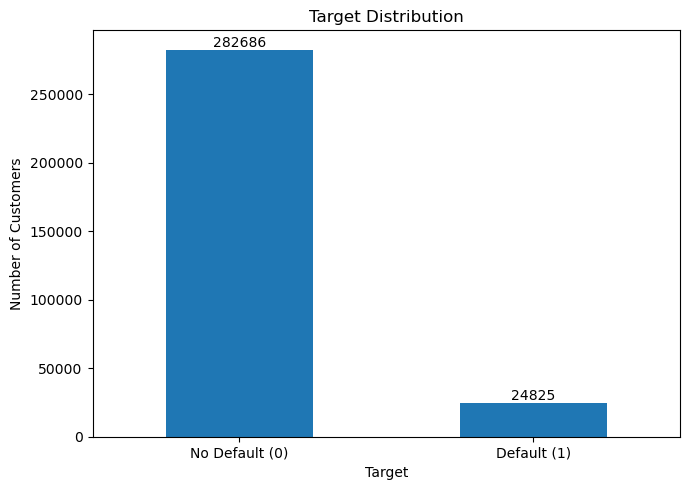

In [72]:
plt.figure(figsize=(7, 5))

ax = df["TARGET"].value_counts().sort_index().plot(
    kind="bar"
)

plt.title("Target Distribution")
plt.xlabel("Target")
plt.ylabel("Number of Customers")
plt.xticks([0, 1], ["No Default (0)", "Default (1)"], rotation=0)

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

In [73]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB


In [74]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

missing.head(20)

COMMONAREA_MEDI             214865
COMMONAREA_AVG              214865
COMMONAREA_MODE             214865
NONLIVINGAPARTMENTS_MEDI    213514
NONLIVINGAPARTMENTS_MODE    213514
NONLIVINGAPARTMENTS_AVG     213514
FONDKAPREMONT_MODE          210295
LIVINGAPARTMENTS_MODE       210199
LIVINGAPARTMENTS_MEDI       210199
LIVINGAPARTMENTS_AVG        210199
FLOORSMIN_MODE              208642
FLOORSMIN_MEDI              208642
FLOORSMIN_AVG               208642
YEARS_BUILD_MODE            204488
YEARS_BUILD_MEDI            204488
YEARS_BUILD_AVG             204488
OWN_CAR_AGE                 202929
LANDAREA_AVG                182590
LANDAREA_MEDI               182590
LANDAREA_MODE               182590
dtype: int64

In [75]:
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_percent = missing_percent[missing_percent > 0].sort_values(ascending=False)

missing_percent.head(20)

COMMONAREA_MEDI             69.872297
COMMONAREA_AVG              69.872297
COMMONAREA_MODE             69.872297
NONLIVINGAPARTMENTS_MEDI    69.432963
NONLIVINGAPARTMENTS_MODE    69.432963
NONLIVINGAPARTMENTS_AVG     69.432963
FONDKAPREMONT_MODE          68.386172
LIVINGAPARTMENTS_MODE       68.354953
LIVINGAPARTMENTS_MEDI       68.354953
LIVINGAPARTMENTS_AVG        68.354953
FLOORSMIN_MODE              67.848630
FLOORSMIN_MEDI              67.848630
FLOORSMIN_AVG               67.848630
YEARS_BUILD_MODE            66.497784
YEARS_BUILD_MEDI            66.497784
YEARS_BUILD_AVG             66.497784
OWN_CAR_AGE                 65.990810
LANDAREA_AVG                59.376738
LANDAREA_MEDI               59.376738
LANDAREA_MODE               59.376738
dtype: float64

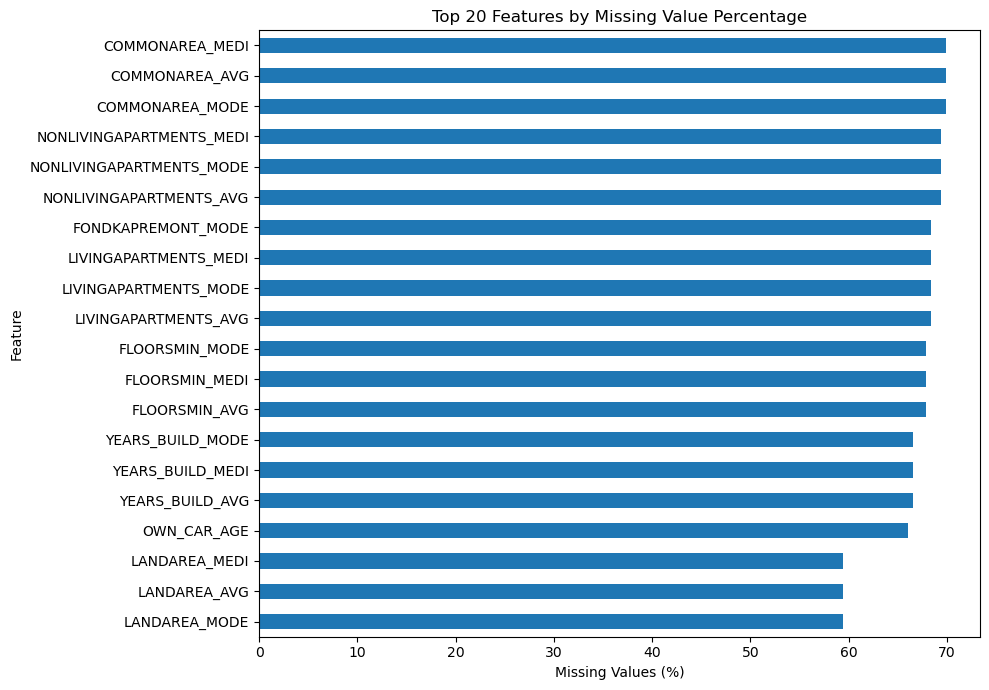

In [76]:
top_missing = missing_percent.head(20).sort_values()

plt.figure(figsize=(10, 7))

top_missing.plot(kind="barh")

plt.title("Top 20 Features by Missing Value Percentage")
plt.xlabel("Missing Values (%)")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [77]:
columns_description = pd.read_csv(
    "data/HomeCredit_columns_description.csv",
    encoding="latin1"
)
columns_description.head(10)

,Unnamed: 0,Table,Row,Description,Special
0,1,application_{train|test}.csv,SK_ID_CURR,ID of loan in our sample,NaN
1,2,application_{train|test}.csv,TARGET,Target variable (1 - client with payment diffi...,NaN
2,5,application_{train|test}.csv,NAME_CONTRACT_TYPE,Identification if loan is cash or revolving,NaN
3,6,application_{train|test}.csv,CODE_GENDER,Gender of the client,NaN
4,7,application_{train|test}.csv,FLAG_OWN_CAR,Flag if the client owns a car,NaN
5,8,application_{train|test}.csv,FLAG_OWN_REALTY,Flag if client owns a house or flat,NaN
6,9,application_{train|test}.csv,CNT_CHILDREN,Number of children the client has,NaN
7,10,application_{train|test}.csv,AMT_INCOME_TOTAL,Income of the client,NaN
8,11,application_{train|test}.csv,AMT_CREDIT,Credit amount of the loan,NaN
9,12,application_{train|test}.csv,AMT_ANNUITY,Loan annuity,NaN


In [78]:
categorical_columns = df.select_dtypes(include="object").columns
categorical_columns

Index(['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY',
       'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
       'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE',
       'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE',
       'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE'],
      dtype='object')

In [79]:
df[categorical_columns].head()

,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,OCCUPATION_TYPE,WEEKDAY_APPR_PROCESS_START,ORGANIZATION_TYPE,FONDKAPREMONT_MODE,HOUSETYPE_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE
0,Cash loans,M,N,Y,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,Laborers,WEDNESDAY,Business Entity Type 3,reg oper account,block of flats,"Stone, brick",No
1,Cash loans,F,N,N,Family,State servant,Higher education,Married,House / apartment,Core staff,MONDAY,School,reg oper account,block of flats,Block,No
2,Revolving loans,M,Y,Y,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,Laborers,MONDAY,Government,NaN,NaN,NaN,NaN
3,Cash loans,F,N,Y,Unaccompanied,Working,Secondary / secondary special,Civil marriage,House / apartment,Laborers,WEDNESDAY,Business Entity Type 3,NaN,NaN,NaN,NaN
4,Cash loans,M,N,Y,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,Core staff,THURSDAY,Religion,NaN,NaN,NaN,NaN


In [80]:
df["NAME_EDUCATION_TYPE"].value_counts(normalize=True)

NAME_EDUCATION_TYPE
Secondary / secondary special    0.710189
Higher education                 0.243448
Incomplete higher                0.033420
Lower secondary                  0.012409
Academic degree                  0.000533
Name: proportion, dtype: float64

In [81]:
df.groupby("NAME_EDUCATION_TYPE")["TARGET"].agg(["count", "mean"])

,count,mean
NAME_EDUCATION_TYPE,,
Academic degree,164,0.018293
Higher education,74863,0.053551
Incomplete higher,10277,0.084850
Lower secondary,3816,0.109277
Secondary / secondary special,218391,0.089399


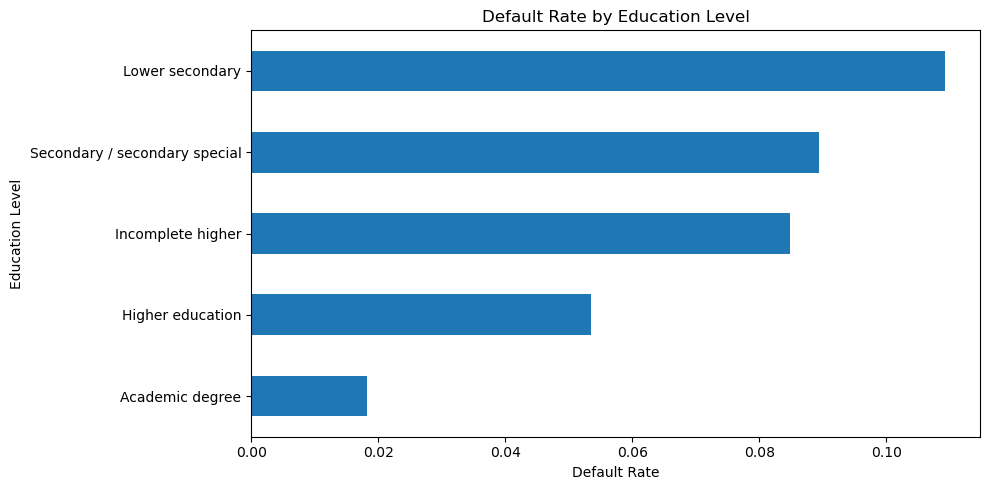

In [82]:
education_default = (
    df.groupby("NAME_EDUCATION_TYPE")["TARGET"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(10, 5))

education_default.plot(kind="barh")

plt.title("Default Rate by Education Level")
plt.xlabel("Default Rate")
plt.ylabel("Education Level")

plt.tight_layout()
plt.show()

**Insight:** Default rates differ across education groups, indicating that applicant profile variables may carry meaningful risk signal. This is a descriptive association, not a causal conclusion, and should not be interpreted as a standalone lending rule.

In [83]:
df["AMT_INCOME_TOTAL"].describe()

count    3.075110e+05
mean     1.687979e+05
std      2.371231e+05
min      2.565000e+04
25%      1.125000e+05
50%      1.471500e+05
75%      2.025000e+05
max      1.170000e+08
Name: AMT_INCOME_TOTAL, dtype: float64

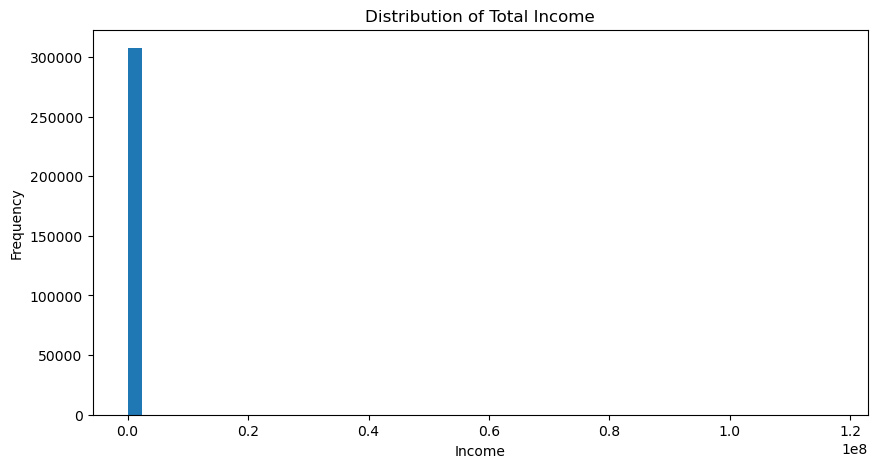

In [84]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.hist(df["AMT_INCOME_TOTAL"], bins=50)
plt.xlabel("Income")
plt.ylabel("Frequency")
plt.title("Distribution of Total Income")
plt.show()

**Insight:** Income is strongly right-skewed, with a small number of very high-income observations. The analysis therefore checks both the raw distribution and a log-transformed view before deciding how the feature should be handled by the model.

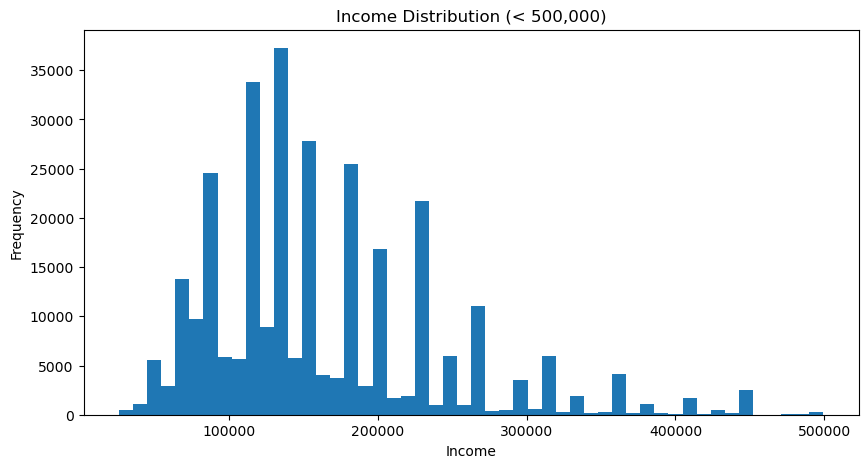

In [85]:
income_filtered = df[df["AMT_INCOME_TOTAL"] < 500000]

plt.figure(figsize=(10, 5))
plt.hist(income_filtered["AMT_INCOME_TOTAL"], bins=50)
plt.xlabel("Income")
plt.ylabel("Frequency")
plt.title("Income Distribution (< 500,000)")
plt.show()

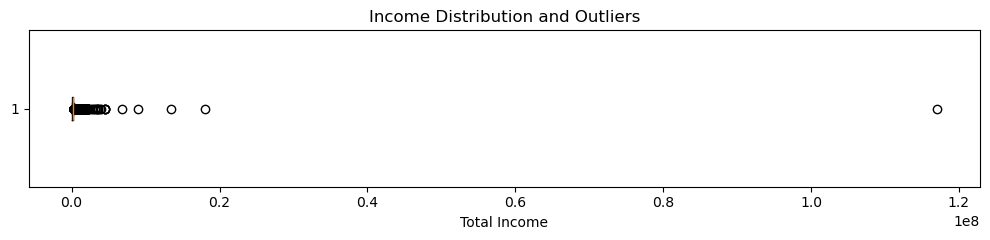

In [86]:
plt.figure(figsize=(10, 2.5))

plt.boxplot(
    df["AMT_INCOME_TOTAL"],
    vert=False
)

plt.title("Income Distribution and Outliers")
plt.xlabel("Total Income")

plt.tight_layout()
plt.show()

In [87]:
df["AMT_INCOME_TOTAL"].skew()

np.float64(391.55965410418776)

In [88]:
import numpy as np

income_log = np.log1p(df["AMT_INCOME_TOTAL"])
income_log.skew()

np.float64(0.1699821010294583)

**Insight:** The log transformation reduces the effect of the long right tail. For the final tree-based model, the raw feature can still be retained because LightGBM does not require normally distributed predictors; the transformation is used here primarily to understand the distribution.

In [89]:
income_bins = [0, 100000, 200000, 300000, 500000, np.inf]

df["INCOME_GROUP"] = pd.cut(
    df["AMT_INCOME_TOTAL"],
    bins=income_bins
)
df.groupby("INCOME_GROUP", observed=True)["TARGET"].agg(["count", "mean"])

,count,mean
INCOME_GROUP,,
"(0.0, 100000.0]",63698,0.082028
"(100000.0, 200000.0]",155898,0.085479
"(200000.0, 300000.0]",65176,0.075503
"(300000.0, 500000.0]",20037,0.060239
"(500000.0, inf]",2702,0.054034


In [90]:
df.drop(columns=["INCOME_GROUP"], inplace=True)

In [91]:
df["CREDIT_INCOME_RATIO"] = (
    df["AMT_CREDIT"] / df["AMT_INCOME_TOTAL"]
)

df["ANNUITY_INCOME_RATIO"] = (
    df["AMT_ANNUITY"] / df["AMT_INCOME_TOTAL"]
)

df["CREDIT_ANNUITY_RATIO"] = (
    df["AMT_CREDIT"] / df["AMT_ANNUITY"]
)

In [92]:
df[[
    "CREDIT_INCOME_RATIO",
    "ANNUITY_INCOME_RATIO",
    "CREDIT_ANNUITY_RATIO"
]].isnull().sum()



CREDIT_INCOME_RATIO      0
ANNUITY_INCOME_RATIO    12
CREDIT_ANNUITY_RATIO    12
dtype: int64

In [93]:
np.isinf(
    df[[
        "CREDIT_INCOME_RATIO",
        "ANNUITY_INCOME_RATIO",
        "CREDIT_ANNUITY_RATIO"
    ]]
).sum()

CREDIT_INCOME_RATIO     0
ANNUITY_INCOME_RATIO    0
CREDIT_ANNUITY_RATIO    0
dtype: int64

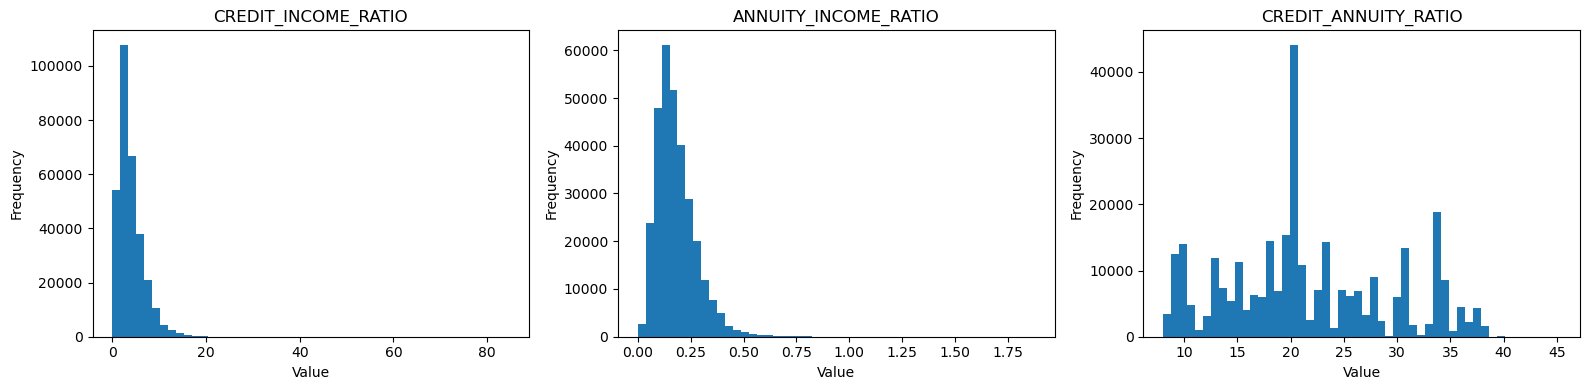

In [94]:
ratio_features = [
    "CREDIT_INCOME_RATIO",
    "ANNUITY_INCOME_RATIO",
    "CREDIT_ANNUITY_RATIO"
]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, feature in zip(axes, ratio_features):
    ax.hist(
        df[feature].replace([np.inf, -np.inf], np.nan).dropna(),
        bins=50
    )
    ax.set_title(feature)
    ax.set_xlabel("Value")
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

**Insight:** Financial burden ratios are often more informative than absolute amounts because they normalize credit obligations relative to income or annuity. These engineered variables provide a more business-oriented view of repayment burden.

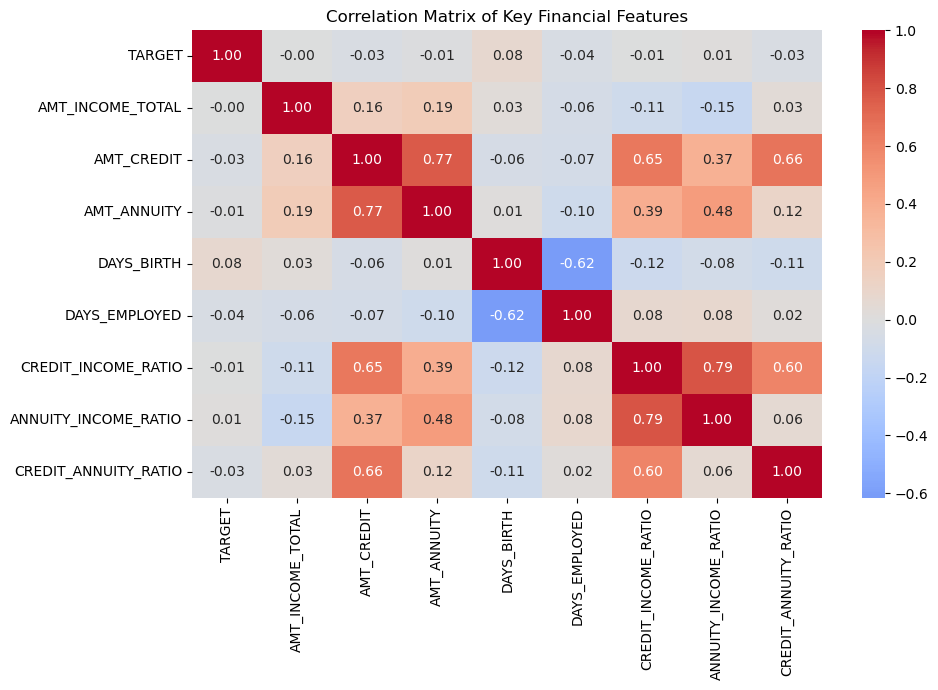

In [95]:
correlation_features = [
    "TARGET",
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "DAYS_BIRTH",
    "DAYS_EMPLOYED",
    "CREDIT_INCOME_RATIO",
    "ANNUITY_INCOME_RATIO",
    "CREDIT_ANNUITY_RATIO"
]

corr = df[correlation_features].corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Key Financial Features")
plt.tight_layout()
plt.show()

**Insight:** The correlation matrix is a screening tool rather than a feature-selection rule. Low linear correlation with `TARGET` does not imply low predictive value because nonlinear relationships and interactions can still be captured by LightGBM.

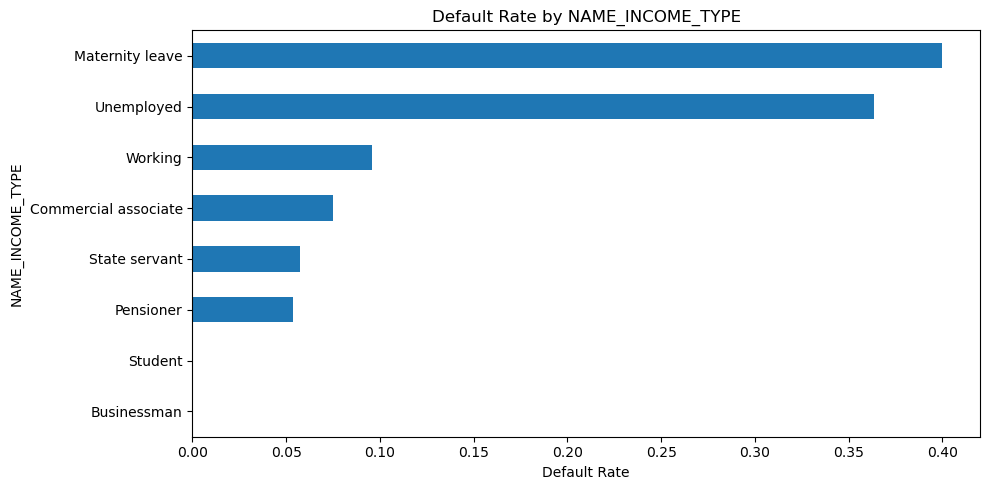

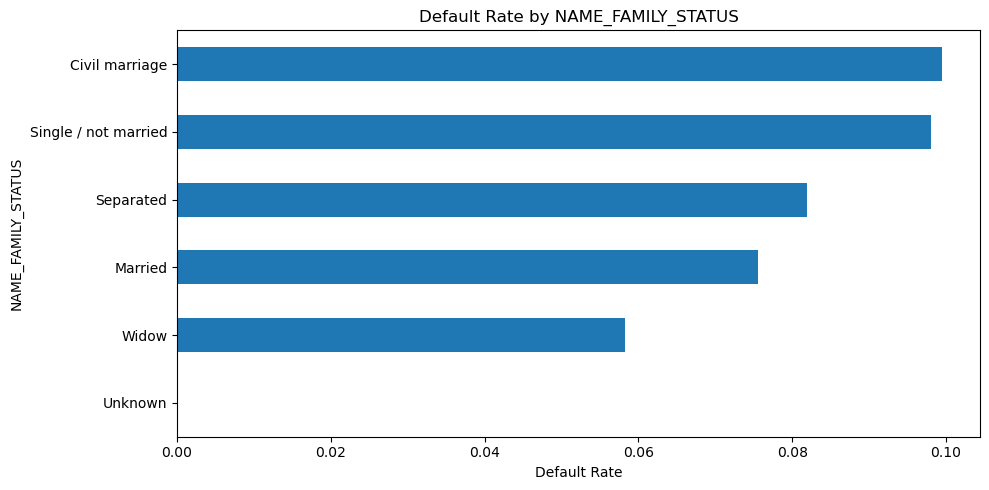

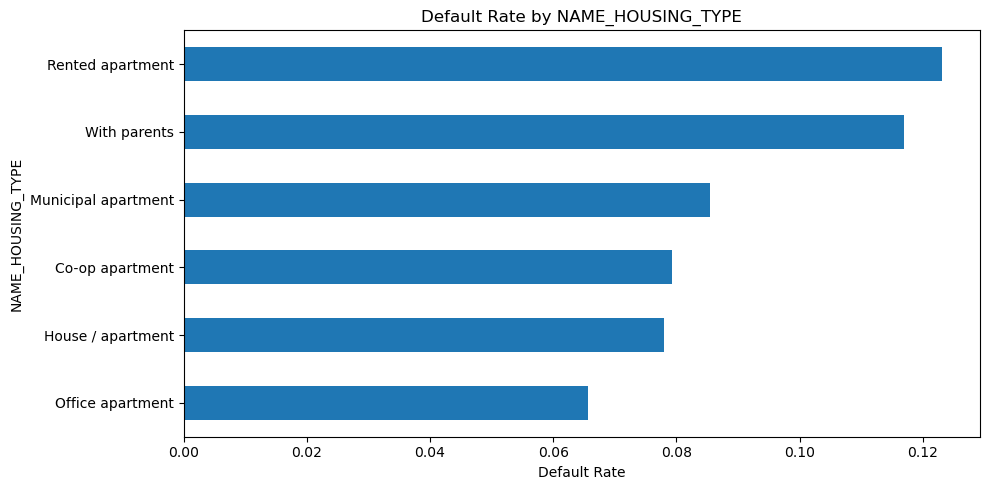

In [96]:
categorical_analysis = [
    "NAME_INCOME_TYPE",
    "NAME_FAMILY_STATUS",
    "NAME_HOUSING_TYPE"
]

for feature in categorical_analysis:

    default_rate = (
        df.groupby(feature)["TARGET"]
        .mean()
        .sort_values()
    )

    plt.figure(figsize=(10, 5))
    default_rate.plot(kind="barh")

    plt.title(f"Default Rate by {feature}")
    plt.xlabel("Default Rate")
    plt.ylabel(feature)

    plt.tight_layout()
    plt.show()

**Insight:** The categorical analyses show that default rates vary across applicant and household profiles. These differences motivate retaining categorical variables and encoding them within the leakage-safe preprocessing pipeline.

## Dataset-specific data-quality checks

`DAYS_EMPLOYED` is a known Home Credit data-quality issue. A very large positive placeholder value can represent applicants for whom employment duration is not observed in the usual form. Rather than allowing this artificial value to behave like a genuine employment duration, we preserve the information with an anomaly flag and replace the placeholder with missing so that the preprocessing pipeline can impute it safely.

In [97]:
DAYS_EMPLOYED_PLACEHOLDER = 365243

df["DAYS_EMPLOYED_ANOM"] = (
    df["DAYS_EMPLOYED"] == DAYS_EMPLOYED_PLACEHOLDER
).astype(int)

print("Placeholder count:", df["DAYS_EMPLOYED_ANOM"].sum())
print(
    "Placeholder share:",
    f"{df['DAYS_EMPLOYED_ANOM'].mean():.2%}"
)

df["DAYS_EMPLOYED"] = df["DAYS_EMPLOYED"].replace(
    DAYS_EMPLOYED_PLACEHOLDER,
    np.nan
)

df[["DAYS_EMPLOYED", "DAYS_EMPLOYED_ANOM"]].head()

Placeholder count: 55374
Placeholder share: 18.01%


,DAYS_EMPLOYED,DAYS_EMPLOYED_ANOM
0,-637.0,0
1,-1188.0,0
2,-225.0,0
3,-3039.0,0
4,-3038.0,0


**Insight:** Treating the placeholder explicitly prevents an artificial value of roughly 1,000 years of employment from being interpreted as a real numeric observation. The anomaly flag also lets the model learn whether this missingness pattern itself contains predictive information.

## `EXT_SOURCE` signal investigation

The external-source variables are particularly important to investigate because they can capture information that is not obvious from the basic financial variables. We therefore inspect their missingness, distributions, and relationship with the target before modeling rather than discovering their importance only after SHAP analysis.

In [98]:
ext_source_features = [
    "EXT_SOURCE_1",
    "EXT_SOURCE_2",
    "EXT_SOURCE_3"
]

ext_source_summary = pd.DataFrame({
    "Missing %": df[ext_source_features].isna().mean() * 100,
    "Mean": df[ext_source_features].mean(),
    "Std": df[ext_source_features].std(),
    "Min": df[ext_source_features].min(),
    "Max": df[ext_source_features].max()
}).round(3)

ext_source_summary

,Missing %,Mean,Std,Min,Max
EXT_SOURCE_1,56.381,0.502,0.211,0.015,0.963
EXT_SOURCE_2,0.215,0.514,0.191,0.000,0.855
EXT_SOURCE_3,19.825,0.511,0.195,0.001,0.896


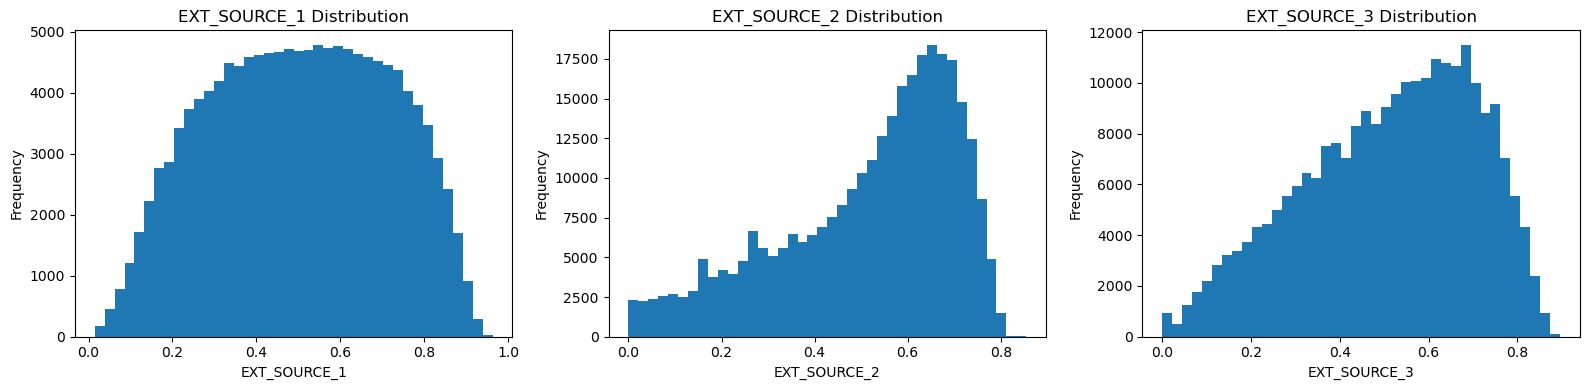

In [99]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, feature in zip(axes, ext_source_features):
    ax.hist(
        df[feature].dropna(),
        bins=40
    )
    ax.set_title(f"{feature} Distribution")
    ax.set_xlabel(feature)
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

In [100]:
ext_source_target_summary = []

for feature in ext_source_features:
    temp = df[[feature, "TARGET"]].dropna().copy()
    temp["Quantile"] = pd.qcut(
        temp[feature],
        q=10,
        duplicates="drop"
    )

    grouped = (
        temp.groupby("Quantile", observed=True)["TARGET"]
        .agg(["count", "mean"])
        .reset_index()
    )
    grouped["Feature"] = feature
    ext_source_target_summary.append(grouped)

ext_source_target_summary = pd.concat(
    ext_source_target_summary,
    ignore_index=True
)

ext_source_target_summary

,Quantile,count,mean,Feature
0,"(0.013600000000000001, 0.213]",13414,0.175637,EXT_SOURCE_1
1,"(0.213, 0.296]",13413,0.115932,EXT_SOURCE_1
2,"(0.296, 0.369]",13414,0.090950,EXT_SOURCE_1
3,"(0.369, 0.438]",13412,0.083806,EXT_SOURCE_1
4,"(0.438, 0.506]",13415,0.066940,EXT_SOURCE_1
5,"(0.506, 0.573]",13412,0.060245,EXT_SOURCE_1
6,"(0.573, 0.64]",13413,0.051368,EXT_SOURCE_1
7,"(0.64, 0.71]",13413,0.043838,EXT_SOURCE_1
8,"(0.71, 0.787]",13413,0.035115,EXT_SOURCE_1
9,"(0.787, 0.963]",13414,0.025719,EXT_SOURCE_1


**Insight:** The `EXT_SOURCE` variables should be discussed alongside the final feature-importance/SHAP results. If higher external-source scores correspond to lower observed default rates, that monotonic pattern provides an intuitive reason why these variables can become dominant predictive signals. Missingness is also material and is handled inside the preprocessing pipeline rather than with information from the full dataset.

## Modeling Preparation

The modeling stage begins only after exploratory analysis. The workflow uses a stratified train/test split, with all preprocessing fitted inside a scikit-learn pipeline. The test set remains untouched by model selection and threshold optimization.

### Missing-value policy

Some variables have substantial missingness. Instead of dropping columns solely because their missing-value percentage is high, the pipeline keeps potentially informative variables and applies median imputation to numeric features and most-frequent imputation to categorical features. This preserves signal while keeping preprocessing reproducible and leakage-safe.

In [101]:
df = df.drop(columns=["SK_ID_CURR"])

X = df.drop(columns=["TARGET"])
y = df["TARGET"]

In [102]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [103]:
print(X_train.shape)
print(X_test.shape)
print(y_train.mean())
print(y_test.mean())

(246008, 124)
(61503, 124)
0.08072908198107379
0.08072776937710356


In [104]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

numeric_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_features = X_train.select_dtypes(
    include=["object"]
).columns

print("Numerical:", len(numeric_features))
print("Categorical:", len(categorical_features))

Numerical: 108
Categorical: 16


In [105]:

# A factory is used instead of a single shared object.
# scikit-learn Pipelines do NOT clone their steps, so reusing one
# ColumnTransformer instance across several pipelines means the same
# object is re-fitted each time. That is a silent-failure risk, so each
# pipeline below gets its own preprocessor.

def build_preprocessor():
    numeric_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median"))
    ])

    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=True
        ))
    ])

    return ColumnTransformer([
        ("num", numeric_pipeline, list(numeric_features)),
        ("cat", categorical_pipeline, list(categorical_features))
    ])

In [106]:

from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline([
    ("preprocessor", build_preprocessor()),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        solver="liblinear",
        random_state=42
    ))
])

logistic_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


**Baseline note:** Logistic Regression is fitted as an interpretable benchmark. Its final comparison with LightGBM is intentionally deferred to the final evaluation stage so that the test set remains untouched during model development.

In [107]:

from lightgbm import LGBMClassifier

lightgbm_model = Pipeline([
    ("preprocessor", build_preprocessor()),
    ("model", LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=31,
        random_state=42,
        n_jobs=-1,
        verbosity=-1
    ))
])

lightgbm_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [108]:
feature_names = lightgbm_model.named_steps["preprocessor"].get_feature_names_out()

feature_importance = pd.Series(
    lightgbm_model.named_steps["model"].feature_importances_,
    index=feature_names
)

print(feature_importance.sort_values(ascending=False).head(20))

num__CREDIT_ANNUITY_RATIO          796
num__EXT_SOURCE_3                  553
num__EXT_SOURCE_1                  534
num__EXT_SOURCE_2                  484
num__DAYS_BIRTH                    409
num__DAYS_EMPLOYED                 359
num__DAYS_ID_PUBLISH               340
num__AMT_ANNUITY                   268
num__DAYS_REGISTRATION             268
num__AMT_GOODS_PRICE               264
num__DAYS_LAST_PHONE_CHANGE        263
num__AMT_CREDIT                    233
num__ANNUITY_INCOME_RATIO          215
num__CREDIT_INCOME_RATIO           206
num__REGION_POPULATION_RELATIVE    187
num__AMT_INCOME_TOTAL              140
num__HOUR_APPR_PROCESS_START       138
num__AMT_REQ_CREDIT_BUREAU_YEAR    109
num__OWN_CAR_AGE                    99
num__TOTALAREA_MODE                 88
dtype: int32


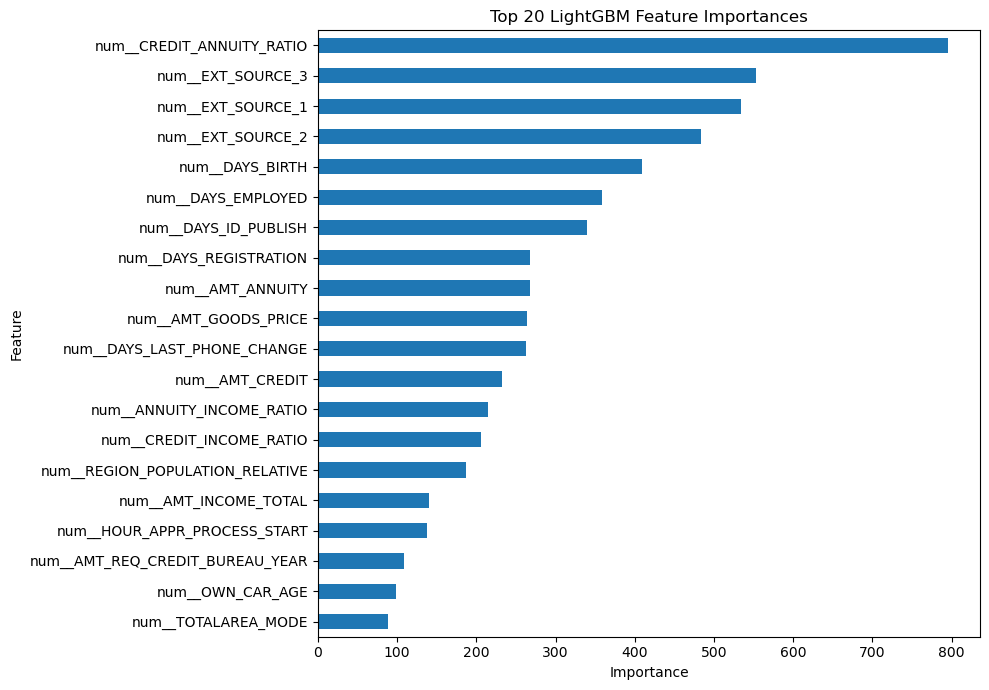

In [109]:
top_features = feature_importance.sort_values(
    ascending=False
).head(20).sort_values()

plt.figure(figsize=(10, 7))

top_features.plot(kind="barh")

plt.title("Top 20 LightGBM Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [110]:

from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

lgbm_pipeline = Pipeline([
    ("preprocessor", build_preprocessor()),
    ("model", LGBMClassifier(
        random_state=42,
        n_jobs=-1,
        verbosity=-1
    ))
])

# class_weight is tuned rather than assumed. Note that class weighting and
# threshold selection overlap: both change how aggressively the model flags
# the positive class. The consequence of that overlap is examined explicitly
# in the threshold section below.
param_distributions = {
    "model__n_estimators": randint(300, 900),
    "model__learning_rate": uniform(0.02, 0.10),
    "model__num_leaves": randint(20, 100),
    "model__max_depth": [-1, 5, 8, 12],
    "model__min_child_samples": randint(20, 150),
    "model__subsample": uniform(0.70, 0.30),
    "model__subsample_freq": [1, 5],
    "model__colsample_bytree": uniform(0.70, 0.30),
    "model__reg_alpha": uniform(0.0, 1.0),
    "model__reg_lambda": uniform(0.0, 2.0),
    "model__class_weight": [None, "balanced"]
}

random_search = RandomizedSearchCV(
    lgbm_pipeline,
    param_distributions=param_distributions,
    n_iter=12,
    cv=3,
    scoring="roc_auc",
    random_state=42,
    n_jobs=-1,
    verbose=1,
    refit=True
)

random_search.fit(X_train, y_train)

Fitting 3 folds for each of 12 candidates, totalling 36 fits


,estimator,Pipeline(step...rbosity=-1))])
,param_distributions,"{'model__class_weight': [None, 'balanced'], 'model__colsample_bytree': <scipy.stats....t 0x309b518c0>, 'model__learning_rate': <scipy.stats....t 0x31ed1ac30>, 'model__max_depth': [-1, 5, ...], ...}"
,n_iter,12
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,3
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [111]:
print("Best Parameters:")
print(random_search.best_params_)
print("\nBest CV ROC-AUC:")
print(random_search.best_score_)


Best Parameters:
{'model__class_weight': 'balanced', 'model__colsample_bytree': np.float64(0.7587948587257435), 'model__learning_rate': np.float64(0.024522728891053808), 'model__max_depth': 12, 'model__min_child_samples': 101, 'model__n_estimators': 352, 'model__num_leaves': 43, 'model__reg_alpha': np.float64(0.3567533266935893), 'model__reg_lambda': np.float64(0.5618690193747615), 'model__subsample': np.float64(0.8628088249474745), 'model__subsample_freq': 1}

Best CV ROC-AUC:
0.7633772101505903


## Model selection and leakage control

The randomized search uses only `X_train` and cross-validation. No metric from `X_test` is used to choose hyperparameters.

The threshold is optimized separately because a probability ranking model and a binary decision rule answer different questions: ROC-AUC evaluates ranking quality, while the threshold determines how aggressively applications are classified as higher risk.

## Threshold selection and probability calibration

Two separate questions are answered in this section:

1. **Are the predicted probabilities trustworthy as probabilities?**
   `class_weight="balanced"` (and imbalanced training in general) inflates
   predicted scores. A model can rank applicants well and still output
   numbers that cannot be read as "chance of default".
2. **Where should the decision cutoff sit?**
   The cutoff is a business policy parameter, not a model parameter.

To answer both without touching the test set, the training data is split
three ways:

| Split | Share of `X_train` | Purpose |
|---|---|---|
| `X_fit` | 70% | fit the LightGBM model |
| `X_cal` | 15% | fit the isotonic calibrator on top of it |
| `X_val` | 15% | select the decision threshold on calibrated probabilities |

Each subset is used for exactly one job, so the threshold is never chosen on
the same rows that produced the calibration mapping.


In [112]:

from sklearn.base import clone
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import precision_score, recall_score, f1_score, brier_score_loss

# 70 / 15 / 15 split of the training data.
X_fit, X_holdout, y_fit, y_holdout = train_test_split(
    X_train, y_train,
    test_size=0.30,
    stratify=y_train,
    random_state=42
)

X_cal, X_val, y_cal, y_val = train_test_split(
    X_holdout, y_holdout,
    test_size=0.50,
    stratify=y_holdout,
    random_state=42
)

print("fit:", X_fit.shape, "calibration:", X_cal.shape, "validation:", X_val.shape)

base_model = clone(random_search.best_estimator_)
base_model.fit(X_fit, y_fit)

# Isotonic calibration on a dedicated, previously unseen split.
# FrozenEstimator is the modern API; cv="prefit" is the older equivalent.
try:
    from sklearn.frozen import FrozenEstimator
    calibrated_model = CalibratedClassifierCV(
        FrozenEstimator(base_model),
        method="isotonic"
    )
except ImportError:
    calibrated_model = CalibratedClassifierCV(
        base_model,
        method="isotonic",
        cv="prefit"
    )

calibrated_model.fit(X_cal, y_cal)

y_val_proba_raw = base_model.predict_proba(X_val)[:, 1]
y_val_proba = calibrated_model.predict_proba(X_val)[:, 1]

print(f"\nValidation base rate:            {y_val.mean():.4f}")
print(f"Mean predicted (uncalibrated):   {y_val_proba_raw.mean():.4f}")
print(f"Mean predicted (calibrated):     {y_val_proba.mean():.4f}")
print(f"Brier, uncalibrated:             {brier_score_loss(y_val, y_val_proba_raw):.4f}")
print(f"Brier, calibrated:               {brier_score_loss(y_val, y_val_proba):.4f}")
print(f"Brier, constant baseline:        {brier_score_loss(y_val, np.full(len(y_val), y_val.mean())):.4f}")

fit: (172205, 124) calibration: (36901, 124) validation: (36902, 124)

Validation base rate:            0.0807
Mean predicted (uncalibrated):   0.3945
Mean predicted (calibrated):     0.0807
Brier, uncalibrated:             0.1853
Brier, calibrated:               0.0678
Brier, constant baseline:        0.0742


In [113]:

thresholds = np.arange(0.01, 0.96, 0.01)

def sweep(y_true, proba):
    rows = []
    for threshold in thresholds:
        pred = (proba >= threshold).astype(int)
        rows.append({
            "threshold": threshold,
            "precision": precision_score(y_true, pred, zero_division=0),
            "recall": recall_score(y_true, pred, zero_division=0),
            "f1": f1_score(y_true, pred, zero_division=0)
        })
    return pd.DataFrame(rows)

sweep_calibrated = sweep(y_val, y_val_proba)
sweep_raw = sweep(y_val, y_val_proba_raw)

best_row = sweep_calibrated.loc[sweep_calibrated["f1"].idxmax()]
best_threshold = float(best_row["threshold"])
raw_best_threshold = float(sweep_raw.loc[sweep_raw["f1"].idxmax(), "threshold"])

print(f"F1-optimal threshold, calibrated probabilities:   {best_threshold:.2f}")
print(f"F1-optimal threshold, uncalibrated probabilities: {raw_best_threshold:.2f}")
print()
print(f"Validation precision: {best_row['precision']:.3f}")
print(f"Validation recall:    {best_row['recall']:.3f}")
print(f"Validation F1:        {best_row['f1']:.3f}")

F1-optimal threshold, calibrated probabilities:   0.17
F1-optimal threshold, uncalibrated probabilities: 0.65

Validation precision: 0.246
Validation recall:    0.412
Validation F1:        0.308


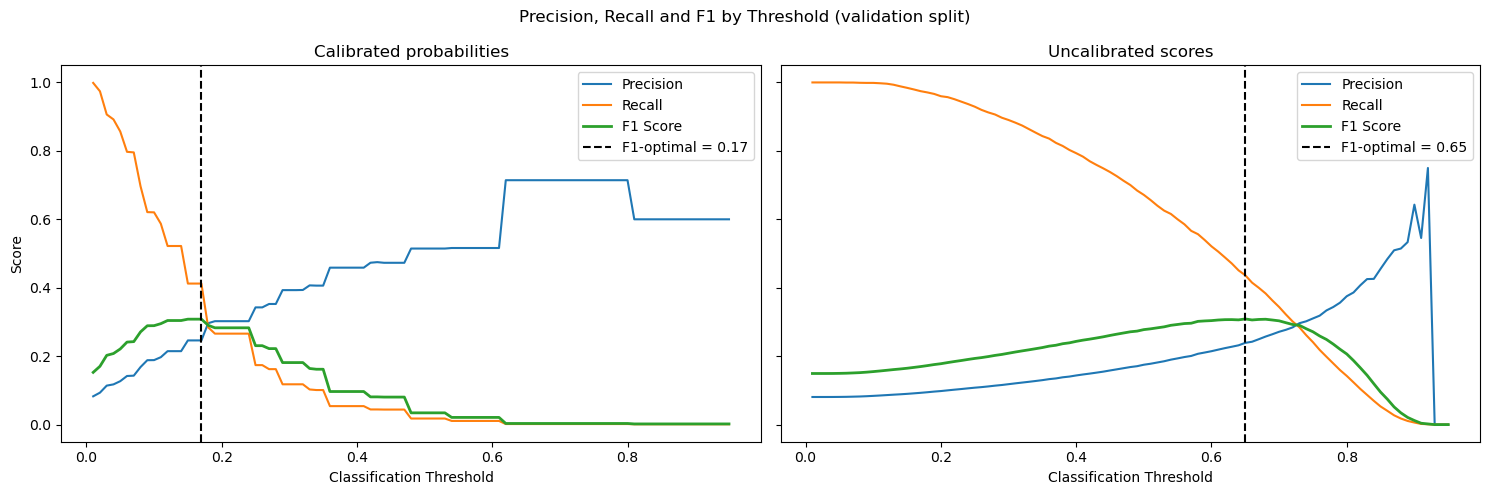

In [114]:

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

for ax, (frame, label, chosen) in zip(
    axes,
    [
        (sweep_calibrated, "Calibrated probabilities", best_threshold),
        (sweep_raw, "Uncalibrated scores", raw_best_threshold)
    ]
):
    ax.plot(frame["threshold"], frame["precision"], label="Precision")
    ax.plot(frame["threshold"], frame["recall"], label="Recall")
    ax.plot(frame["threshold"], frame["f1"], label="F1 Score", linewidth=2)
    ax.axvline(chosen, linestyle="--", color="black",
               label=f"F1-optimal = {chosen:.2f}")
    ax.set_title(label)
    ax.set_xlabel("Classification Threshold")
    ax.legend()

axes[0].set_ylabel("Score")
plt.suptitle("Precision, Recall and F1 by Threshold (validation split)")
plt.tight_layout()
plt.show()

**Interpretation:** The two panels make the class-weighting / threshold
overlap visible. Because `class_weight="balanced"` already rescales the
positive class during training, the *uncalibrated* F1-optimal cutoff lands
close to the conventional `0.50` — which makes a "0.50 vs tuned" comparison
look like it does nothing. After calibration the scores return to a
probability scale where the base rate is roughly 8%, and the F1-optimal
cutoff moves well below `0.50`.

The lesson worth stating in a portfolio context: class weighting and
threshold tuning are two levers on the same mechanism. Applying both without
checking leaves the impression that the threshold work was unnecessary.


### A cost-based alternative to F1

F1 treats a missed default and a wrongly rejected applicant as equally
important. In lending they are not: the loss on a defaulted loan is far
larger than the foregone margin on a rejected good applicant.

With calibrated probabilities the decision rule has a closed form. If a
false negative costs `C_fn` and a false positive costs `C_fp`, expected cost
is minimised by approving whenever

`p < C_fp / (C_fp + C_fn)`

The curve below sweeps the threshold empirically at an assumed 10:1 cost
ratio and confirms that the minimum sits near that analytical value.


Cost-optimal threshold (empirical):  0.10
Cost-optimal threshold (analytical): 0.09


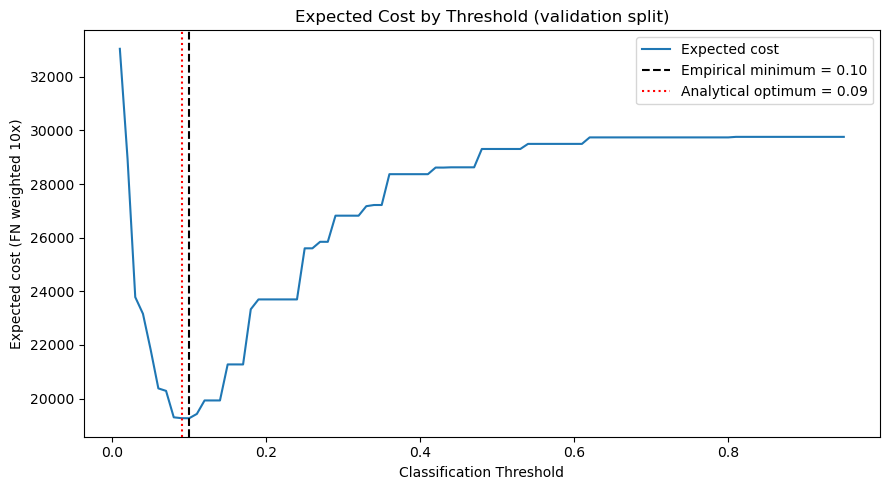

In [115]:

COST_FN = 10.0   # cost of approving an applicant who defaults
COST_FP = 1.0    # cost of rejecting an applicant who would have repaid

costs = []
for threshold in thresholds:
    pred = (y_val_proba >= threshold).astype(int)
    false_negatives = int(((pred == 0) & (y_val == 1)).sum())
    false_positives = int(((pred == 1) & (y_val == 0)).sum())
    costs.append({
        "threshold": threshold,
        "false_negatives": false_negatives,
        "false_positives": false_positives,
        "total_cost": COST_FN * false_negatives + COST_FP * false_positives
    })

cost_frame = pd.DataFrame(costs)
cost_threshold = float(cost_frame.loc[cost_frame["total_cost"].idxmin(), "threshold"])
analytical_threshold = COST_FP / (COST_FP + COST_FN)

print(f"Cost-optimal threshold (empirical):  {cost_threshold:.2f}")
print(f"Cost-optimal threshold (analytical): {analytical_threshold:.2f}")

plt.figure(figsize=(9, 5))
plt.plot(cost_frame["threshold"], cost_frame["total_cost"], label="Expected cost")
plt.axvline(cost_threshold, linestyle="--", color="black",
            label=f"Empirical minimum = {cost_threshold:.2f}")
plt.axvline(analytical_threshold, linestyle=":", color="red",
            label=f"Analytical optimum = {analytical_threshold:.2f}")
plt.xlabel("Classification Threshold")
plt.ylabel(f"Expected cost (FN weighted {COST_FN:.0f}x)")
plt.title("Expected Cost by Threshold (validation split)")
plt.legend()
plt.tight_layout()
plt.show()

**Deployment choice:** the F1-optimal threshold is kept as the deployed
default so that the exported artifact stays comparable with the metrics
reported below, and the cost-optimal threshold is exported alongside it as a
documented alternative. The point of the exercise is that the cutoff is an
explicit, auditable business input rather than an unexamined `0.50`.


## Final Model Evaluation

All modelling decisions are now frozen: hyperparameters came from
cross-validation on `X_train`, the calibrator was fitted on `X_cal`, and the
threshold was chosen on `X_val`. The test set is used from this point
onward for reporting only.

Two fitted objects are carried forward:

- `calibrated_model` — the deployment artifact (LightGBM fitted on `X_fit`,
  wrapped in an isotonic calibrator fitted on `X_cal`).
- `final_model` — the same LightGBM configuration refitted on the *full*
  training set, uncalibrated. It is kept as a reference point for the
  discrimination-vs-calibration comparison and is the object used for SHAP,
  since isotonic calibration is a monotone transform and therefore does not
  change the ordering that the explanations describe.


In [116]:

from sklearn.metrics import (
    roc_auc_score, average_precision_score, confusion_matrix,
    classification_report, roc_curve, precision_recall_curve
)

final_model = clone(random_search.best_estimator_)
final_model.fit(X_train, y_train)

y_test_proba_raw = final_model.predict_proba(X_test)[:, 1]
y_test_proba = calibrated_model.predict_proba(X_test)[:, 1]
y_test_pred = (y_test_proba >= best_threshold).astype(int)

print(f"Deployed threshold: {best_threshold:.2f}")
print(f"Test ROC-AUC (calibrated model):   {roc_auc_score(y_test, y_test_proba):.4f}")
print(f"Test PR-AUC  (calibrated model):   {average_precision_score(y_test, y_test_proba):.4f}")
print(f"Test PR-AUC  random baseline:      {y_test.mean():.4f}")

print("\nConfusion Matrix at Deployed Threshold:")
print(confusion_matrix(y_test, y_test_pred))

print("\nClassification Report at Deployed Threshold:")
print(classification_report(y_test, y_test_pred, zero_division=0))

Deployed threshold: 0.17
Test ROC-AUC (calibrated model):   0.7671
Test PR-AUC  (calibrated model):   0.2436
Test PR-AUC  random baseline:      0.0807

Confusion Matrix at Deployed Threshold:
[[50571  5967]
 [ 2916  2049]]

Classification Report at Deployed Threshold:
              precision    recall  f1-score   support

           0       0.95      0.89      0.92     56538
           1       0.26      0.41      0.32      4965

    accuracy                           0.86     61503
   macro avg       0.60      0.65      0.62     61503
weighted avg       0.89      0.86      0.87     61503



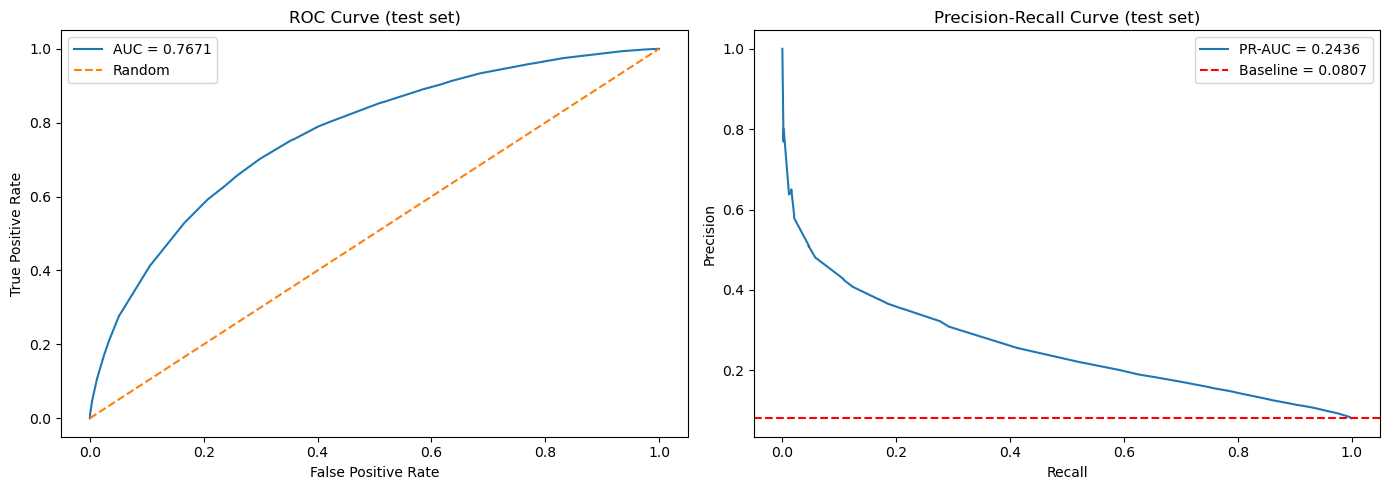

In [117]:

fpr, tpr, _ = roc_curve(y_test, y_test_proba)
precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_test_proba)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_test_proba):.4f}")
axes[0].plot([0, 1], [0, 1], linestyle="--", label="Random")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve (test set)")
axes[0].legend()

axes[1].plot(recall_curve, precision_curve,
             label=f"PR-AUC = {average_precision_score(y_test, y_test_proba):.4f}")
axes[1].axhline(y_test.mean(), linestyle="--", color="red",
                label=f"Baseline = {y_test.mean():.4f}")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve (test set)")
axes[1].legend()

plt.tight_layout()
plt.show()

### Reading the operating point in business terms

A confusion matrix is easier to defend when it is restated as a policy. The
next cell converts the deployed cutoff into the two numbers a credit officer
would actually ask for: what share of applicants gets flagged, and what share
of defaults gets caught.


In [118]:

def operating_point(name, threshold, proba):
    pred = (proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    return {
        "Policy": name,
        "Threshold": round(float(threshold), 3),
        "Flagged %": round(100 * pred.mean(), 1),
        "Defaults caught %": round(100 * tp / (tp + fn), 1),
        "Precision": round(precision_score(y_test, pred, zero_division=0), 4),
        "Recall": round(recall_score(y_test, pred, zero_division=0), 4),
        "F1": round(f1_score(y_test, pred, zero_division=0), 4),
        "Good applicants rejected": int(fp)
    }

policy_comparison = pd.DataFrame([
    operating_point("Conventional 0.50", 0.50, y_test_proba),
    operating_point("F1-optimal (deployed)", best_threshold, y_test_proba),
    operating_point("Cost-optimal (10:1)", cost_threshold, y_test_proba)
])

policy_comparison

,Policy,Threshold,Flagged %,Defaults caught %,Precision,Recall,F1,Good applicants rejected
0,Conventional 0.50,0.50,0.3,2.1,0.5787,0.0207,0.0401,75
1,F1-optimal (deployed),0.17,13.0,41.3,0.2556,0.4127,0.3157,5967
2,Cost-optimal (10:1),0.10,26.3,62.2,0.1907,0.6224,0.2920,13112


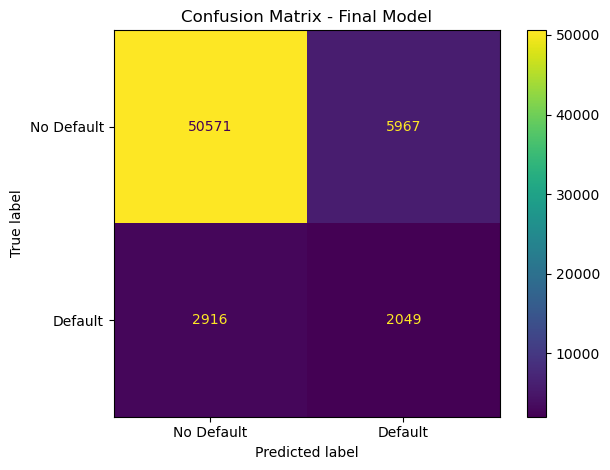

In [119]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred,
    display_labels=["No Default", "Default"]
)

plt.title("Confusion Matrix - Final Model")
plt.tight_layout()
plt.show()


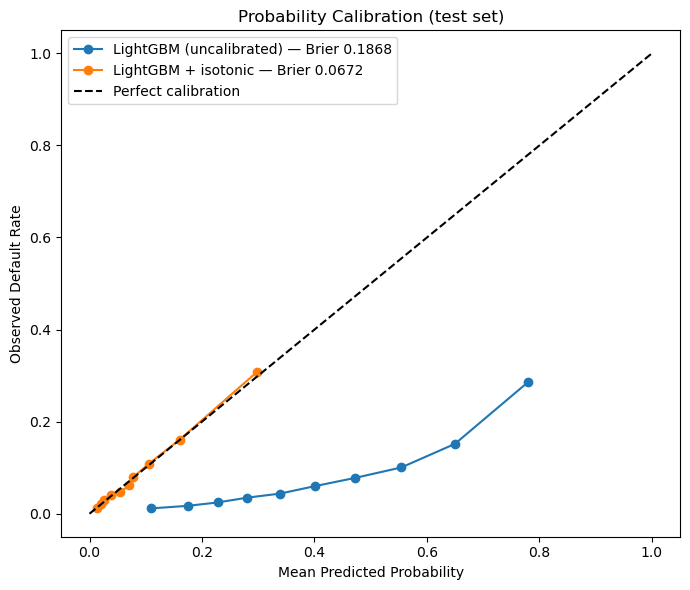

Brier, uncalibrated:      0.1868
Brier, calibrated:        0.0672
Brier, constant baseline: 0.0742

Test base rate:            0.0807
Mean predicted, uncal.:   0.3988
Mean predicted, cal.:     0.0802


In [120]:

from sklearn.calibration import calibration_curve

fig, ax = plt.subplots(figsize=(7, 6))

for proba, label in [
    (y_test_proba_raw, "LightGBM (uncalibrated)"),
    (y_test_proba, "LightGBM + isotonic")
]:
    prob_true, prob_pred = calibration_curve(
        y_test, proba, n_bins=10, strategy="quantile"
    )
    ax.plot(prob_pred, prob_true, marker="o",
            label=f"{label} — Brier {brier_score_loss(y_test, proba):.4f}")

baseline_brier = brier_score_loss(y_test, np.full(len(y_test), y_train.mean()))
ax.plot([0, 1], [0, 1], linestyle="--", color="black", label="Perfect calibration")
ax.set_xlabel("Mean Predicted Probability")
ax.set_ylabel("Observed Default Rate")
ax.set_title("Probability Calibration (test set)")
ax.legend()

plt.tight_layout()
plt.show()

print(f"Brier, uncalibrated:      {brier_score_loss(y_test, y_test_proba_raw):.4f}")
print(f"Brier, calibrated:        {brier_score_loss(y_test, y_test_proba):.4f}")
print(f"Brier, constant baseline: {baseline_brier:.4f}")
print(f"\nTest base rate:            {y_test.mean():.4f}")
print(f"Mean predicted, uncal.:   {y_test_proba_raw.mean():.4f}")
print(f"Mean predicted, cal.:     {y_test_proba.mean():.4f}")

**Evaluation takeaway:** ROC-AUC and PR-AUC measure *ranking*, and isotonic
calibration leaves ranking essentially untouched — so those numbers barely
move. What changes is the meaning of the output. The uncalibrated model
scores a typical applicant far above the 8% base rate, which is harmless for
ranking and actively misleading if the number is shown to a user as a
percentage. The constant-baseline Brier score is the reference that makes
this concrete: a model whose Brier score is worse than "always predict the
base rate" has good discrimination and unusable probabilities.

This is the reason the deployed artifact is the calibrated pipeline rather
than the raw LightGBM model.


In [121]:

# Each model is compared at its own validation-selected F1 threshold.
# Comparing all models at 0.50 would not be meaningful, because
# class_weight="balanced" and calibration place the models on different
# probability scales.
def select_threshold(model, X_reference, y_reference):
    proba = model.predict_proba(X_reference)[:, 1]
    scores = [f1_score(y_reference, (proba >= t).astype(int), zero_division=0)
              for t in thresholds]
    return float(thresholds[int(np.argmax(scores))])

models = {
    "Logistic Regression": logistic_model,
    "LightGBM (default params)": lightgbm_model,
    "Tuned LightGBM": final_model,
    "Tuned LightGBM + isotonic": calibrated_model
}

model_comparison = []
for name, model in models.items():
    model_threshold = select_threshold(model, X_val, y_val)
    probabilities = model.predict_proba(X_test)[:, 1]
    predictions = (probabilities >= model_threshold).astype(int)

    model_comparison.append({
        "Model": name,
        "Threshold": round(model_threshold, 3),
        "ROC-AUC": roc_auc_score(y_test, probabilities),
        "PR-AUC": average_precision_score(y_test, probabilities),
        "Brier": brier_score_loss(y_test, probabilities),
        "Precision": precision_score(y_test, predictions, zero_division=0),
        "Recall": recall_score(y_test, predictions, zero_division=0),
        "F1": f1_score(y_test, predictions, zero_division=0)
    })

comparison_df = (
    pd.DataFrame(model_comparison)
    .sort_values("ROC-AUC", ascending=False)
    .reset_index(drop=True)
    .round(4)
)

comparison_df

,Model,Threshold,ROC-AUC,PR-AUC,Brier,Precision,Recall,F1
0,Tuned LightGBM,0.67,0.7699,0.2600,0.1868,0.2577,0.4171,0.3186
1,LightGBM (default params),0.17,0.7677,0.2595,0.0671,0.2751,0.3815,0.3197
2,Tuned LightGBM + isotonic,0.17,0.7671,0.2436,0.0672,0.2556,0.4127,0.3157
3,Logistic Regression,0.59,0.6793,0.1641,0.2257,0.1749,0.3482,0.2329


## Final Model Feature Importance

The final fitted LightGBM model is used for the portfolio-level feature-importance view. Feature importance indicates which transformed variables are used heavily by the model; SHAP is then used to explain both direction and magnitude of individual contributions.

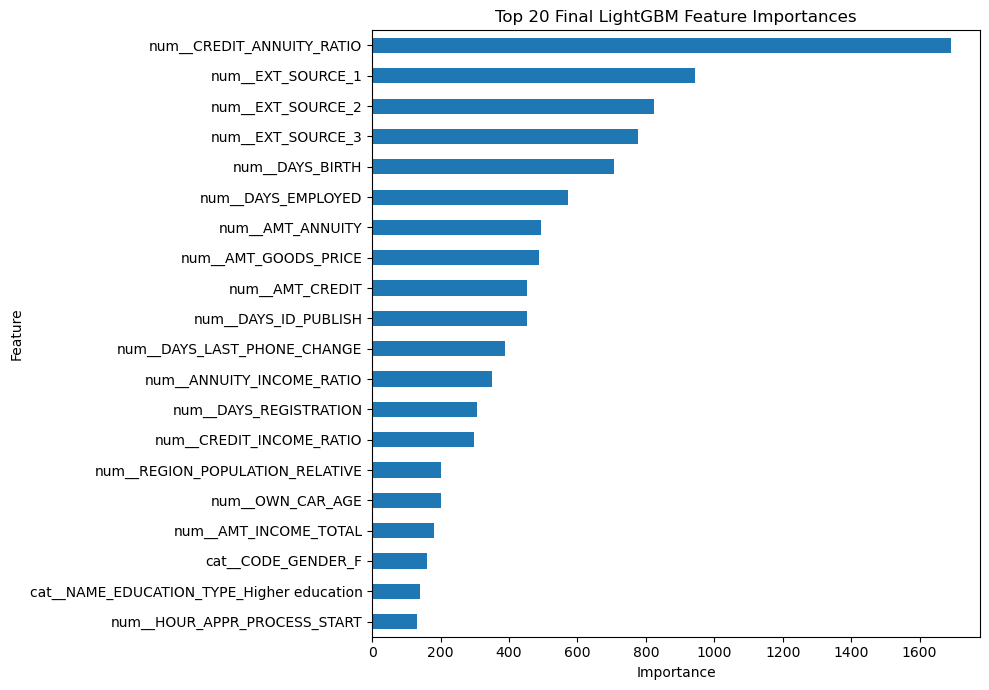

In [122]:
final_feature_names = final_model.named_steps["preprocessor"].get_feature_names_out()

final_feature_importance = pd.Series(
    final_model.named_steps["model"].feature_importances_,
    index=final_feature_names
).sort_values(ascending=False)

final_top_features = final_feature_importance.head(20).sort_values()

plt.figure(figsize=(10, 7))
final_top_features.plot(kind="barh")
plt.title("Top 20 Final LightGBM Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


## Explainability with SHAP

SHAP is applied to the final LightGBM model. The global explanation identifies the variables that most influence predictions across a sample, while the local explanation shows which features push one selected application toward higher or lower predicted risk.

Because this is a credit-risk use case, the explanations are treated as decision-support diagnostics rather than proof of causality or fairness.

In [123]:
import shap

X_test_transformed = final_model.named_steps["preprocessor"].transform(X_test)
feature_names = final_model.named_steps["preprocessor"].get_feature_names_out()
model = final_model.named_steps["model"]

explainer = shap.TreeExplainer(model)
shap_test_values = explainer.shap_values(X_test_transformed)

# SHAP API compatibility for binary classification across SHAP versions.
if isinstance(shap_test_values, list):
    shap_test_values = shap_test_values[1]


In [124]:
sample_size = min(5000, X_test_transformed.shape[0])
X_shap = X_test_transformed[:sample_size]
shap_values_sample = shap_test_values[:sample_size]


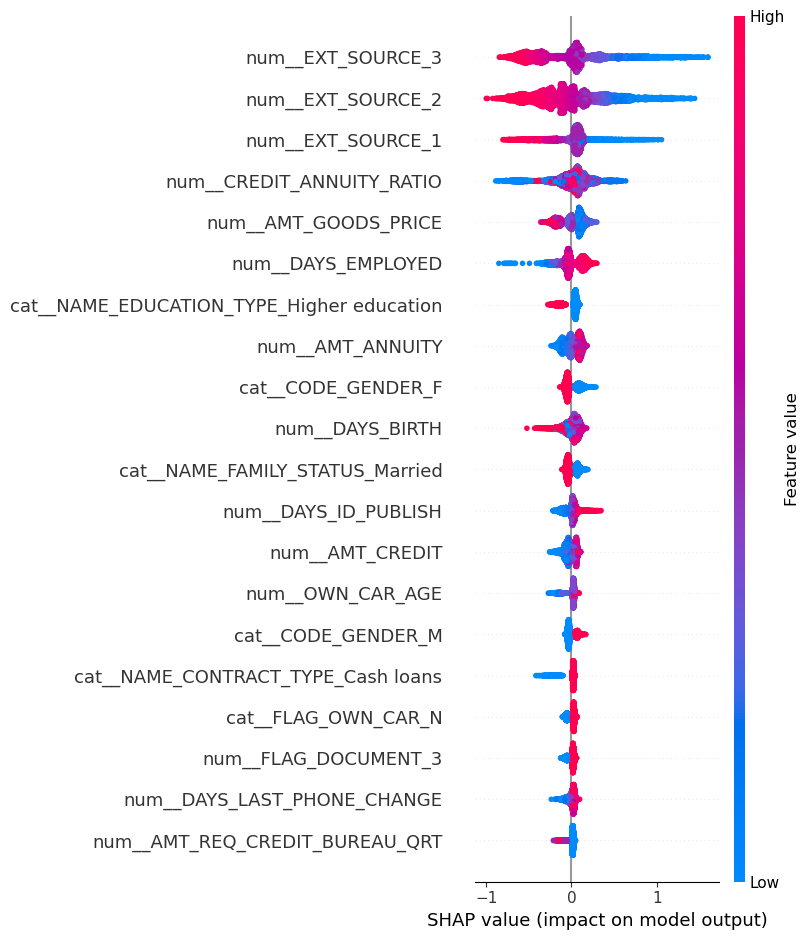

In [125]:
shap.summary_plot(
    shap_values_sample,
    X_shap,
    feature_names=feature_names,
    max_display=20
)


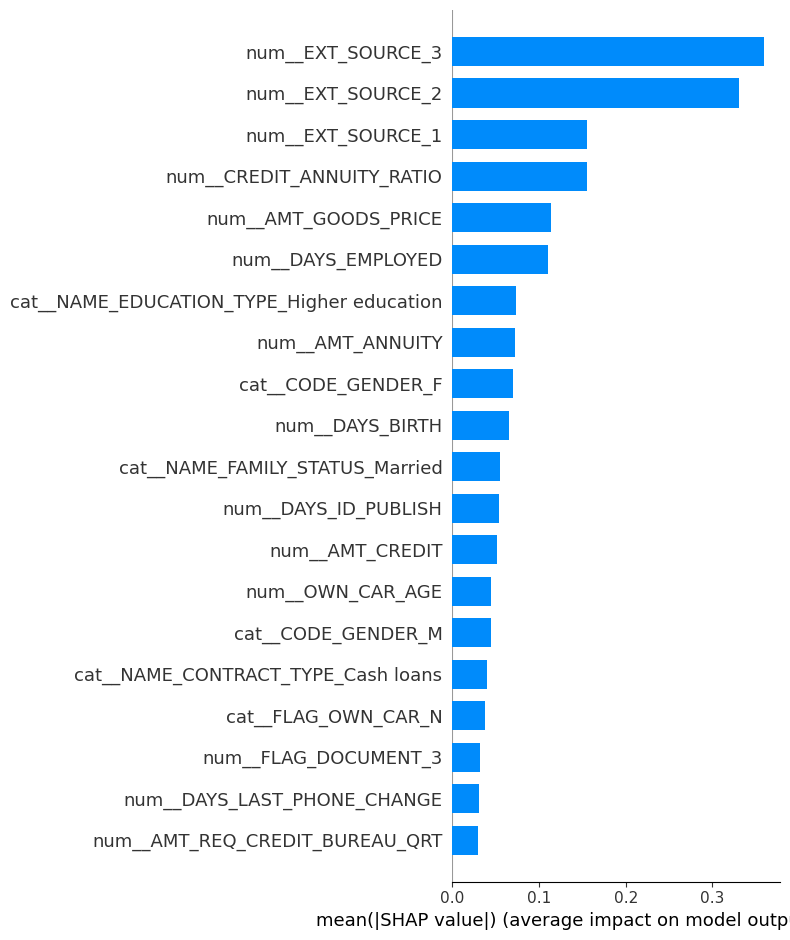

In [126]:
shap.summary_plot(
    shap_values_sample,
    X_shap,
    feature_names=feature_names,
    plot_type="bar",
    max_display=20
)


**SHAP insight:** If `EXT_SOURCE_2` and `EXT_SOURCE_3` appear among the strongest contributors, that connects the early EDA to the final model: the variables were investigated before modeling and later confirmed as important predictive signals. The SHAP result should be described as model behavior, not as a causal claim.

In [127]:

# The SHAP values were computed from `final_model`, so the customer is
# selected using that model's scores to keep the two consistent.
high_risk_index = int(np.argmax(y_test_proba_raw))

print(f"Calibrated risk probability: {y_test_proba[high_risk_index]:.4f}")
print(f"Actual target:               {y_test.iloc[high_risk_index]}")

Calibrated risk probability: 1.0000
Actual target:               1


In [128]:
customer_shap = shap_test_values[high_risk_index]

customer_explanation = pd.DataFrame({
    "Feature": feature_names,
    "SHAP Value": customer_shap
})

customer_explanation["Abs SHAP"] = customer_explanation["SHAP Value"].abs()
customer_explanation = customer_explanation.sort_values(
    "Abs SHAP",
    ascending=False
)

customer_explanation.head(10)


,Feature,SHAP Value,Abs SHAP
28,num__EXT_SOURCE_2,0.915637,0.915637
29,num__EXT_SOURCE_3,0.791776,0.791776
106,num__CREDIT_ANNUITY_RATIO,0.204303,0.204303
4,num__AMT_GOODS_PRICE,0.137515,0.137515
181,cat__ORGANIZATION_TYPE_Construction,0.112714,0.112714
3,num__AMT_ANNUITY,0.085293,0.085293
7,num__DAYS_EMPLOYED,0.085114,0.085114
6,num__DAYS_BIRTH,0.085086,0.085086
110,cat__CODE_GENDER_F,0.067088,0.067088
19,num__REGION_RATING_CLIENT_W_CITY,0.064871,0.064871


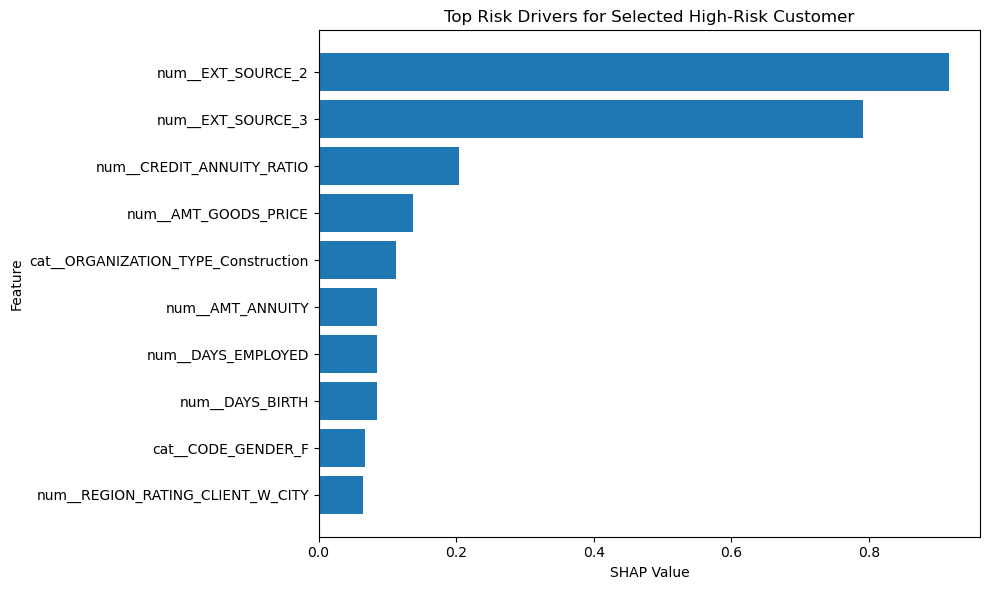

In [129]:
top_customer_features = (
    customer_explanation
    .head(10)
    .sort_values("SHAP Value")
)

plt.figure(figsize=(10, 6))
plt.barh(
    top_customer_features["Feature"],
    top_customer_features["SHAP Value"]
)
plt.axvline(0, linestyle="--")
plt.xlabel("SHAP Value")
plt.ylabel("Feature")
plt.title("Top Risk Drivers for Selected High-Risk Customer")
plt.tight_layout()
plt.show()


**Local explanation:** This view answers a practical question — *why did this particular application receive a high predicted risk?* Positive SHAP values push the prediction toward higher risk, while negative values push it toward lower risk. It is an explanation of the model's output, not a standalone lending decision.

## Fairness screening

The model is trained on the raw Home Credit columns, which include
`CODE_GENDER`. In most jurisdictions a deployed credit model may not use
protected attributes such as gender as an input, and even excluding the
column does not by itself guarantee an even-handed outcome, because other
features can proxy for it.

Two checks are run below:

1. **Outcome parity** — flag rate, approval rate and per-group AUC across
   gender groups at the deployed threshold.
2. **Cost of exclusion** — how much discrimination is lost if the column is
   dropped from the feature set entirely.

The web demo shipped with this project does **not** collect gender; this
section documents why.


In [130]:

gender_report = []

for group in X_test["CODE_GENDER"].dropna().unique():
    mask = (X_test["CODE_GENDER"] == group).to_numpy()
    if mask.sum() < 100:
        continue

    group_true = y_test.to_numpy()[mask]
    group_proba = y_test_proba[mask]
    group_pred = (group_proba >= best_threshold).astype(int)

    gender_report.append({
        "Group": group,
        "N": int(mask.sum()),
        "Observed default rate": round(float(group_true.mean()), 4),
        "Mean predicted": round(float(group_proba.mean()), 4),
        "Flag rate": round(float(group_pred.mean()), 4),
        "AUC": round(float(roc_auc_score(group_true, group_proba)), 4)
              if len(np.unique(group_true)) > 1 else np.nan
    })

gender_frame = pd.DataFrame(gender_report).sort_values("N", ascending=False)
gender_frame

,Group,N,Observed default rate,Mean predicted,Flag rate,AUC
1,F,40561,0.0699,0.0703,0.1006,0.7597
0,M,20940,0.1017,0.0993,0.1879,0.7676


In [131]:

# How much predictive power comes from the gender column itself?
gender_free_features = [c for c in X_train.columns if c != "CODE_GENDER"]

numeric_features_gf = [c for c in numeric_features if c in gender_free_features]
categorical_features_gf = [c for c in categorical_features if c in gender_free_features]

gender_free_preprocessor = ColumnTransformer([
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]),
     numeric_features_gf),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=True))
    ]), categorical_features_gf)
])

gender_free_model = Pipeline([
    ("preprocessor", gender_free_preprocessor),
    ("model", clone(random_search.best_estimator_.named_steps["model"]))
])

gender_free_model.fit(X_train[gender_free_features], y_train)
gender_free_proba = gender_free_model.predict_proba(X_test[gender_free_features])[:, 1]

print(f"Test ROC-AUC with CODE_GENDER:    {roc_auc_score(y_test, y_test_proba_raw):.4f}")
print(f"Test ROC-AUC without CODE_GENDER: {roc_auc_score(y_test, gender_free_proba):.4f}")
print(f"Difference:                       "
      f"{roc_auc_score(y_test, y_test_proba_raw) - roc_auc_score(y_test, gender_free_proba):+.4f}")

Test ROC-AUC with CODE_GENDER:    0.7699
Test ROC-AUC without CODE_GENDER: 0.7685
Difference:                       +0.0015


**Reading the result:** a small AUC difference means the protected attribute
carries little unique information once the other features are present, which
weakens any argument for keeping it. A large group gap in flag rate, on the
other hand, is not resolved by dropping the column — it would require
explicit fairness constraints, reject-inference work and legal review, all of
which are out of scope for a portfolio project and are listed as limitations.


## Save Deployment Artifacts

The calibrated pipeline is exported together with a configuration file that
records the decision threshold, the engineered-feature definitions and the
library versions used at training time.

The engineered features matter here specifically: `CREDIT_INCOME_RATIO`,
`ANNUITY_INCOME_RATIO`, `CREDIT_ANNUITY_RATIO` and `DAYS_EMPLOYED_ANOM` are
created in this notebook *before* the pipeline runs, which means any serving
code must recreate them with identical formulas. Writing the definitions into
the config makes that contract explicit instead of leaving it implicit in two
separate code paths.

Library versions are pinned in the config because a joblib artifact is a
pickle: loading it under a different scikit-learn version can fail outright.


In [132]:

from pathlib import Path
import joblib
import json
import sklearn
import lightgbm

artifacts_dir = Path("artifacts")
artifacts_dir.mkdir(exist_ok=True)

joblib.dump(calibrated_model, artifacts_dir / "credit_risk_model.joblib")

model_config = {
    "model": "LightGBM + isotonic calibration",
    "search": "RandomizedSearchCV",
    "calibrated": True,
    "calibration_method": "isotonic",
    "target": "TARGET",
    "random_state": 42,

    "threshold": float(best_threshold),
    "threshold_metric": "F1 on calibrated validation probabilities",
    "threshold_alternatives": {
        "conventional": 0.50,
        "cost_optimal_10_to_1": float(cost_threshold),
        "f1_optimal_uncalibrated": float(raw_best_threshold)
    },

    "train_default_rate": float(y_train.mean()),

    "engineered_features": {
        "CREDIT_INCOME_RATIO": "AMT_CREDIT / AMT_INCOME_TOTAL",
        "ANNUITY_INCOME_RATIO": "AMT_ANNUITY / AMT_INCOME_TOTAL",
        "CREDIT_ANNUITY_RATIO": "AMT_CREDIT / AMT_ANNUITY",
        "DAYS_EMPLOYED_ANOM": "1 if DAYS_EMPLOYED == 365243 else 0"
    },
    "days_employed_placeholder": 365243,

    "test_metrics": {
        "roc_auc": float(roc_auc_score(y_test, y_test_proba)),
        "pr_auc": float(average_precision_score(y_test, y_test_proba)),
        "brier": float(brier_score_loss(y_test, y_test_proba)),
        "brier_constant_baseline": float(baseline_brier)
    },

    "versions": {
        "scikit_learn": sklearn.__version__,
        "lightgbm": lightgbm.__version__,
        "pandas": pd.__version__,
        "numpy": np.__version__
    }
}

with open(artifacts_dir / "model_config.json", "w") as f:
    json.dump(model_config, f, indent=4)

print("Saved:", artifacts_dir / "credit_risk_model.joblib")
print("Saved:", artifacts_dir / "model_config.json")
print()
print(json.dumps(model_config, indent=4))

Saved: artifacts/credit_risk_model.joblib
Saved: artifacts/model_config.json

{
    "model": "LightGBM + isotonic calibration",
    "search": "RandomizedSearchCV",
    "calibrated": true,
    "calibration_method": "isotonic",
    "target": "TARGET",
    "random_state": 42,
    "threshold": 0.17,
    "threshold_metric": "F1 on calibrated validation probabilities",
    "threshold_alternatives": {
        "conventional": 0.5,
        "cost_optimal_10_to_1": 0.1,
        "f1_optimal_uncalibrated": 0.65
    },
    "train_default_rate": 0.08072908198107379,
    "engineered_features": {
        "CREDIT_INCOME_RATIO": "AMT_CREDIT / AMT_INCOME_TOTAL",
        "ANNUITY_INCOME_RATIO": "AMT_ANNUITY / AMT_INCOME_TOTAL",
        "CREDIT_ANNUITY_RATIO": "AMT_CREDIT / AMT_ANNUITY",
        "DAYS_EMPLOYED_ANOM": "1 if DAYS_EMPLOYED == 365243 else 0"
    },
    "days_employed_placeholder": 365243,
    "test_metrics": {
        "roc_auc": 0.7671233032871475,
        "pr_auc": 0.2436279876610353,
        

## Business Interpretation

**Business objective:** estimate the probability that a loan applicant will
experience payment difficulties, then support risk-based decision making.

**Data-quality treatment:** the `DAYS_EMPLOYED` placeholder is flagged and
removed from the numeric scale, and `EXT_SOURCE_1/2/3` are investigated
during EDA because they carry the strongest signal in the dataset.

**Modelling approach:** Logistic Regression provides an interpretable
baseline; LightGBM captures nonlinear structure and interactions.
Hyperparameters come from a cross-validated randomised search scored on
ROC-AUC.

**Probability quality:** the tuned model discriminates well but is not
well-calibrated, because imbalanced training and class weighting inflate the
predicted scores. Isotonic calibration on a dedicated split restores the
probability scale, which is what makes the output safe to display to a user
as a percentage.

**Decision policy:** the cutoff is treated as a business input. An
F1-optimal threshold is selected on a validation split and deployed, with a
cost-optimal threshold under a 10:1 loss assumption exported alongside it.
The operating point is reported as flag rate and share of defaults caught,
not only as precision and recall.

**Evaluation:** the test set is used once, after every modelling decision is
frozen, for discrimination, thresholded performance and calibration.

**Explainability:** feature importance and SHAP give global and
customer-level views of model behaviour.

**Fairness:** gender is screened for outcome disparity and for its marginal
contribution to AUC, and it is excluded from the serving interface.

**Important limitation:** this is a portfolio project on the public Home
Credit dataset, and it uses only `application_train.csv` — the `bureau`,
`previous_application`, `installments_payments` and related tables are out of
scope. Adding them is the single largest available improvement. It is not a
production credit decision system: that would require out-of-time validation,
reject inference, formal fairness constraints, drift and stability
monitoring, regulatory review and model governance.


## Portfolio checklist

- [x] Target imbalance documented
- [x] `DAYS_EMPLOYED` placeholder handled explicitly
- [x] `EXT_SOURCE_1/2/3` investigated during EDA
- [x] EDA findings converted into written insights
- [x] Preprocessing kept inside a scikit-learn pipeline, one instance per model
- [x] Hyperparameter search with cross-validation
- [x] Class weighting and threshold tuning shown to overlap, not stacked blindly
- [x] Train split into fit / calibration / validation subsets with distinct roles
- [x] Probabilities calibrated, not only measured
- [x] Brier score compared against a constant-prediction baseline
- [x] Threshold selected on validation data, reported as a business policy
- [x] Cost-based threshold derived and cross-checked analytically
- [x] Test set reserved for a single final evaluation
- [x] ROC, PR and calibration curves plotted
- [x] Models compared at their own thresholds, not a shared 0.50
- [x] Global and local SHAP explanations included
- [x] Fairness screened across gender groups
- [x] Model, threshold, feature-engineering contract and library versions exported
- [x] Serving code shares the feature-engineering contract with training

> **Run order:** use *Kernel → Restart & Run All* from the project root so
> that `data/` and `artifacts/` resolve and execution counts read cleanly
> from 1.
